<a href="https://colab.research.google.com/github/M-Iswarya2/CarPricePred/blob/main/carPricePred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [230]:
import kagglehub
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

Using Colab cache for faster access to the 'vehicle-dataset-from-cardekho' dataset.


In [231]:
import os
import pandas as pd
df = pd.read_csv(os.path.join(path, "car data.csv"))

In [232]:
import numpy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import matplotlib.pyplot as plt

In [233]:
print(df[:5])
print(df.shape)
print(df.columns)

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  
(301, 9)
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [234]:
df.nunique()

,0
Car_Name,98
Year,16
Selling_Price,156
Present_Price,147
Kms_Driven,206
Fuel_Type,3
Seller_Type,2
Transmission,2
Owner,3


In [235]:
df.drop("Car_Name",axis=1)

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [236]:
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=False)
df=pd.get_dummies(df,columns=["Seller_Type","Transmission"],drop_first=True)
#one hot encoding kind of... and all these columns has only 2 values ... so drop_first does if n cols are there ...makes n-1 columns...

In [237]:
print(df[:5])
print(df.columns)

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven  Owner  \
0     ritz  2014           3.35           5.59       27000      0   
1      sx4  2013           4.75           9.54       43000      0   
2     ciaz  2017           7.25           9.85        6900      0   
3  wagon r  2011           2.85           4.15        5200      0   
4    swift  2014           4.60           6.87       42450      0   

   Fuel_Type_CNG  Fuel_Type_Diesel  Fuel_Type_Petrol  Seller_Type_Individual  \
0          False             False              True                   False   
1          False              True             False                   False   
2          False             False              True                   False   
3          False             False              True                   False   
4          False              True             False                   False   

   Transmission_Manual  
0                 True  
1                 True  
2                 True  
3   

In [238]:
df.drop("Car_Name",axis=1,inplace=True)

In [239]:
df.dtypes

,0
Year,int64
Selling_Price,float64
Present_Price,float64
Kms_Driven,int64
Owner,int64
Fuel_Type_CNG,bool
Fuel_Type_Diesel,bool
Fuel_Type_Petrol,bool
Seller_Type_Individual,bool
Transmission_Manual,bool


In [240]:
df.corr()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104,-0.017790,0.064315,-0.059959,-0.039896,0.000394
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344,-0.025164,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057,-0.011500,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216,0.012223,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000,-0.014272,-0.053469,0.055687,0.124269,-0.050316
Fuel_Type_CNG,-0.017790,-0.025164,-0.011500,0.012223,-0.014272,1.000000,-0.040808,-0.160577,-0.060300,0.032018
Fuel_Type_Diesel,0.064315,0.552339,0.473306,0.172515,-0.053469,-0.040808,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.059959,-0.540571,-0.465244,-0.172874,0.055687,-0.160577,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.039896,-0.550724,-0.512030,-0.101419,0.124269,-0.060300,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,0.000394,-0.367128,-0.348715,-0.162510,-0.050316,0.032018,-0.098643,0.091013,0.063240,1.000000


In [241]:
price_corr=abs(df.corr()["Selling_Price"])
price_corr.sort_values(ascending=False)

,Selling_Price
Selling_Price,1.000000
Present_Price,0.878983
Fuel_Type_Diesel,0.552339
Seller_Type_Individual,0.550724
Fuel_Type_Petrol,0.540571
Transmission_Manual,0.367128
Year,0.236141
Owner,0.088344
Kms_Driven,0.029187
Fuel_Type_CNG,0.025164


In [242]:
df=df.drop('Fuel_Type_CNG',axis=1)
df=df.astype(float)


In [243]:
X=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]

In [244]:
print(X.dtypes)
print(X.describe)

Year                      float64
Present_Price             float64
Kms_Driven                float64
Owner                     float64
Fuel_Type_Diesel          float64
Fuel_Type_Petrol          float64
Seller_Type_Individual    float64
Transmission_Manual       float64
dtype: object
<bound method NDFrame.describe of        Year  Present_Price  Kms_Driven  Owner  Fuel_Type_Diesel  \
0    2014.0           5.59     27000.0    0.0               0.0   
1    2013.0           9.54     43000.0    0.0               1.0   
2    2017.0           9.85      6900.0    0.0               0.0   
3    2011.0           4.15      5200.0    0.0               0.0   
4    2014.0           6.87     42450.0    0.0               1.0   
..      ...            ...         ...    ...               ...   
296  2016.0          11.60     33988.0    0.0               1.0   
297  2015.0           5.90     60000.0    0.0               0.0   
298  2009.0          11.00     87934.0    0.0               0.0   
299  2017.

In [245]:
X= (X - X.min()) / (X.max() - X.min())

In [246]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
loss=mean_squared_error(y_test,y_pred)
print("MSE:",loss)
r2_sc=r2_score(y_test,y_pred)
print("R2 Score:",r2_sc)

MSE: 2.7506892621397685
R2 Score: 0.8502332355855586


In [247]:
for i in range(len(X.columns)):
    print(X.columns[i],model.coef_[i])

Year 6.096168375972866
Present_Price 39.56993911505862
Kms_Driven -2.9586229322279145
Owner -2.5470291798735394
Fuel_Type_Diesel 2.8605628495115916
Fuel_Type_Petrol 0.7031035502317735
Seller_Type_Individual -1.074773471245667
Transmission_Manual -1.5089797453609128


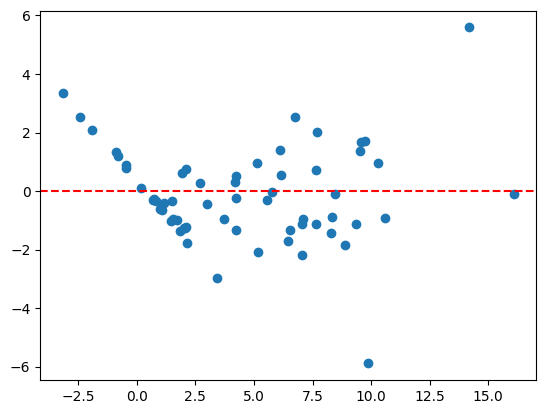

In [248]:
residuals=y_test-y_pred
plt.axhline(y=0,color="red",ls="--")
plt.scatter(y_pred,residuals)

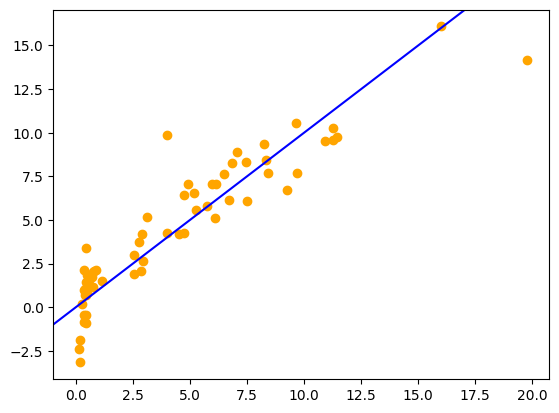

In [249]:
plt.scatter(y_test,y_pred,color="orange")
plt.axline((0,0), slope=1, color="blue")

In [250]:
df.corr()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.236141,-0.047584,-0.524342,-0.182104,0.064315,-0.059959,-0.039896,0.000394
Selling_Price,0.236141,1.000000,0.878983,0.029187,-0.088344,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.008057,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,0.089216,0.172515,-0.172874,-0.101419,-0.162510
Owner,-0.182104,-0.088344,0.008057,0.089216,1.000000,-0.053469,0.055687,0.124269,-0.050316
Fuel_Type_Diesel,0.064315,0.552339,0.473306,0.172515,-0.053469,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,-0.059959,-0.540571,-0.465244,-0.172874,0.055687,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,-0.039896,-0.550724,-0.512030,-0.101419,0.124269,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,0.000394,-0.367128,-0.348715,-0.162510,-0.050316,-0.098643,0.091013,0.063240,1.000000


In [251]:
print(X.dtypes)
X=X.astype(float)
print("After conversion so i can get vif ..")
print(X.dtypes)

Year                      float64
Present_Price             float64
Kms_Driven                float64
Owner                     float64
Fuel_Type_Diesel          float64
Fuel_Type_Petrol          float64
Seller_Type_Individual    float64
Transmission_Manual       float64
dtype: object
After conversion so i can get vif ..
Year                      float64
Present_Price             float64
Kms_Driven                float64
Owner                     float64
Fuel_Type_Diesel          float64
Fuel_Type_Petrol          float64
Seller_Type_Individual    float64
Transmission_Manual       float64
dtype: object


Variation Inflation Factor is used to know if there is multi collinearity example: A correlates with B,
B correlates with C,
A may indirectly correlate with C.
This can confuse regression.

To detect this we use Variance Inflation Factor (VIF).

In [252]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
for i in range(len(X.columns)):
    print(X.columns[i],variance_inflation_factor(X.values,i))


Year 18.37588490805847
Present_Price 3.065842922575259
Kms_Driven 2.6124257214410367
Owner 1.0864461621976056
Fuel_Type_Diesel 9.474617862449016
Fuel_Type_Petrol 28.45040909387095
Seller_Type_Individual 2.2226128378224344
Transmission_Manual 8.171461496265314


In [253]:
import numpy as np
arr=[]
for i in range(len(X.columns)):
  arr.append([X.columns[i],model.coef_[i]])
arr.sort(key=lambda x:abs(x[1]),reverse=True)
print(np.array(arr))


[['Present_Price' '39.56993911505862']
 ['Year' '6.096168375972866']
 ['Kms_Driven' '-2.9586229322279145']
 ['Fuel_Type_Diesel' '2.8605628495115916']
 ['Owner' '-2.5470291798735394']
 ['Transmission_Manual' '-1.5089797453609128']
 ['Seller_Type_Individual' '-1.074773471245667']
 ['Fuel_Type_Petrol' '0.7031035502317735']]


**Using Lasso regression now! cause there is multi collinearity**


In [261]:
from sklearn.linear_model import Lasso
model=Lasso(alpha=0.001)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
loss=mean_squared_error(y_test,y_pred)
print("MSE:",loss)
r2_sc=r2_score(y_test,y_pred)
print("R2 Score:",r2_sc)

MSE: 2.7534578808694685
R2 Score: 0.8500824926155142


In [262]:
arr=[]
for i in range(len(X.columns)):
  arr.append([X.columns[i],model.coef_[i]])
arr.sort(key=lambda x:abs(x[1]),reverse=True)
print(np.array(arr))

[['Present_Price' '39.41771906524781']
 ['Year' '6.107563220793241']
 ['Kms_Driven' '-2.7870827467653974']
 ['Owner' '-2.4188399132120137']
 ['Fuel_Type_Diesel' '2.3839896101080194']
 ['Transmission_Manual' '-1.506252925399573']
 ['Seller_Type_Individual' '-1.081114085663553']
 ['Fuel_Type_Petrol' '0.21770796529209532']]
